In [ ]:
%pip install puremacro


# Crecimiento en Riesgo: la cola izquierda vulnerable

¿Qué tan mal podría ir el crecimiento? No el panorama medio, sino el *riesgo a la
baja*: el resultado de Adrian-Boyarchenko-Giannone (2019) es que el endurecimiento de
las condiciones financieras desplaza los cuantiles **inferiores** del crecimiento
futuro del PIB mucho más que la mediana — el riesgo a la baja es el fenómeno central.
Construimos un índice de condiciones financieras, estimamos una autorregresión
cuantílica y ajustamos una densidad condicional skew-t con `puremacro.gar`, todo en el
navegador y con datos sintéticos.

## El método en ecuaciones

**Regresión cuantílica.** Los mínimos cuadrados apuntan a la *media* condicional; para
trazar un *cuantil* condicional sustituimos la pérdida cuadrática por la **pérdida de
verificación (pinball)** asimétrica
$$ \rho_\tau(u) = u\,\bigl(\tau - \mathbb{1}\{u<0\}\bigr),\qquad \tau\in(0,1). $$
Minimizar $\sum_t \rho_\tau\!\bigl(y_{t+h}-x_t'\beta\bigr)$ sobre $\beta$ devuelve los
coeficientes del cuantil condicional
$$ Q_\tau\!\left(y_{t+h}\mid x_t\right) = x_t'\beta(\tau). $$
La subestimación se penaliza con peso $\tau$ y la sobreestimación con peso $1-\tau$;
para $\tau=\tfrac12$ esto es la desviación absoluta mínima (la mediana), y un $\tau$
pequeño inclina el ajuste hacia la cola inferior. Se estima una regresión por cada
$\tau$ y se permite que las pendientes $\beta(\tau)$ *difieran* a lo largo de la
distribución — que es justamente lo que ponemos a prueba.

**El Crecimiento en Riesgo** es el cuantil condicional de la cola inferior,
$$ \text{GaR}_{0.05} \;=\; Q_{0.05}\!\left(y_{t+h}\mid x_t\right), $$
el nivel de crecimiento que se supera con probabilidad del 95% dadas las condiciones
actuales. El hallazgo empírico de ABG es la asimetría: con un índice de condiciones
financieras (FCI) como condicionante $x_t$, la pendiente $\partial Q_\tau/\partial\text{FCI}$
es marcadamente negativa en $\tau=0.05$ pero cercana a cero en la mediana — la
restricción devora la cola izquierda, no el centro.

**Densidad skew-t.** Unos pocos cuantiles estimados $\{Q_\tau\}$ ya bosquejan una
distribución; ABG recuperan la densidad condicional *completa* ajustando la **skew-t**
de Azzalini $f(\cdot\mid\mu,\sigma,\alpha,\nu)$ por emparejamiento de cuantiles,
$$ (\hat\mu,\hat\sigma,\hat\alpha,\hat\nu)=\arg\min \sum_\tau\bigl(F^{-1}(\tau;\mu,\sigma,\alpha,\nu)-Q_\tau\bigr)^2, $$
lo que entrega una localización $\mu$, una escala $\sigma$, una **asimetría** $\alpha$
y un grosor de cola (grados de libertad) $\nu$ — cuatro parámetros de forma donde una
gaussiana tiene solo dos.

**Lo que calcula este cuaderno.** Un FCI sintético a partir de un panel de cinco
indicadores; una autorregresión cuantílica del crecimiento del PIB sobre dos rezagos
propios más ese FCI, en la rejilla $\tau\in\{0.05,0.50,0.95\}$ (y
$\{0.05,0.25,0.50,0.75,0.95\}$ para la densidad); y un ajuste skew-t a los cuantiles
predichos bajo un FCI laxo frente a uno restrictivo.

**Intuición.** La *mediana* condicional puede verse perfectamente saludable mientras la
*cola izquierda* se deteriora en silencio — una economía puede tener un pronóstico
central respetable y aun así estar a un choque de una contracción aguda. El Crecimiento
en Riesgo lee esa cola izquierda directamente, de modo que se mueve cuando el riesgo *a
la baja* aumenta aunque el pronóstico puntual no lo haga. ¿Por qué una skew-t y no una
gaussiana? Las recesiones no son la imagen especular de las expansiones: la distribución
del crecimiento es **asimétrica a la izquierda** (la cola mala es más larga) y de **colas
pesadas** (las contracciones extremas son más probables de lo que admite una campana). El
parámetro $\alpha$ de la skew-t capta la asimetría y su $\nu$ las colas pesadas, de modo
que sigue la distribución condicional del crecimiento macroeconómico donde una gaussiana
de dos parámetros no puede.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_cwd = Path.cwd()
sys.path.insert(0, str(_cwd if (_cwd / "_nbstyle.py").exists() else _cwd / "notebooks"))
import _nbstyle
_nbstyle.apply_style()

from puremacro.gar import qar, fci, fit_skewt_to_quantiles

rng = np.random.default_rng(20240529)

## 1. Un índice de condiciones financieras a partir de un panel de indicadores sintéticos
Un factor latente persistente de "restricción" impulsa cinco indicadores financieros
(los diferenciales de crédito y la volatilidad cargan positivamente; los precios de
activos, negativamente). `fci` extrae el primer componente principal y lo normaliza en
signo de modo que **mayor = condiciones más restrictivas**.

In [2]:
T = 320  # quarters
f = np.zeros(T)
rho_f = 0.85
for t in range(1, T):
    f[t] = rho_f * f[t - 1] + 0.6 * rng.standard_normal()
load = np.array([1.0, 0.8, 1.2, -0.9, 0.7])             # equity loads negative
fin = f[:, None] * load + 0.4 * rng.standard_normal((T, load.size))
fin_df = pd.DataFrame(fin, columns=["spread", "vol", "credit", "equity", "term"])

fci_out = fci(fin_df, tightening_columns=["spread", "vol", "credit"])
FCI = fci_out["index"].values                           # standardized; higher = tighter
var_exp = fci_out["var_explained"]
print(f"FCI variance explained by first PC = {var_exp:.3f}")
assert 0.3 < var_exp < 1.0, var_exp

FCI variance explained by first PC = 0.897


## 2. Crecimiento sintético del PIB con cola izquierda vulnerable
Las condiciones más restrictivas reducen la media condicional *y* engordan la cola
inferior (la escala del choque negativo aumenta con el `FCI`, mientras que la escala
positiva permanece constante) — este es el mecanismo de "crecimiento vulnerable" de
Adrian-Boyarchenko-Giannone.

In [3]:
g = np.zeros(T)
phi, mu0, beta_mean = 0.30, 2.0, -0.35
for t in range(1, T):
    tight = FCI[t - 1]
    scale_dn = 1.0 + 1.6 * np.maximum(tight, 0.0)       # fat left tail when tight
    e = rng.standard_normal()
    shock = scale_dn * min(e, 0.0) + 1.0 * max(e, 0.0)
    g[t] = mu0 + phi * (g[t - 1] - mu0) + beta_mean * tight + shock

## 3. Autorregresión cuantílica con el FCI como control
`qar` estima una fila por cada `(h, tau)`; con `p=2` rezagos más un control, la
disposición de coeficientes es `beta0` (intercepto), `beta1, beta2` (rezagos AR),
`beta3` (coeficiente sobre el FCI). La prueba de asimetría: la pendiente del FCI en
el percentil 5 es considerablemente más negativa que la de la mediana.

In [4]:
taus = (0.05, 0.50, 0.95)
out = qar(g, quantiles=taus, horizons=(1,), p=2,
          controls=FCI, n_boot=200, alpha=0.10, seed=7)
fci_col = "beta3"                                        # p=2 lags -> FCI is beta3
slopes = out.set_index("tau")[fci_col]
qpred = out.set_index("tau")["q_pred"]
print(out[["tau", "q_pred", "lo", "hi", fci_col]].to_string(index=False))

slope_05, slope_50, slope_95 = slopes.loc[0.05], slopes.loc[0.50], slopes.loc[0.95]
print(f"\nFCI slope:  tau=0.05 -> {slope_05:.3f}   tau=0.50 -> {slope_50:.3f}"
      f"   tau=0.95 -> {slope_95:.3f}")
assert slope_05 < slope_50, (slope_05, slope_50)                 # left tail more exposed
assert abs(slope_05) > abs(slope_50), (slope_05, slope_50)       # ABG asymmetry
assert qpred.loc[0.05] < qpred.loc[0.50] < qpred.loc[0.95], qpred.to_dict()

 tau    q_pred        lo        hi     beta3
0.05 -0.294918 -1.715062 -0.051650 -1.422216
0.50  0.891006  0.629681  2.125299 -0.804038
0.95  2.878708  2.270007  3.285026 -0.517815

FCI slope:  tau=0.05 -> -1.422   tau=0.50 -> -0.804   tau=0.95 -> -0.518


**Lectura del resultado.** Los tres números de `beta3` son las cargas del FCI de los
tres cuantiles, y son el corazón del resultado. La pendiente de la mediana es pequeña
— un FCI más restrictivo apenas mueve el pronóstico central — mientras que la pendiente
del percentil 5 es grande y negativa: el endurecimiento arrastra con fuerza el *fondo*
de la distribución. Esa brecha (`|pendiente τ=0.05| ≫ |pendiente τ=0.50|`) es la
asimetría de ABG, y por ella la columna `q_pred` ya se abre en abanico, con el percentil
5 muy por debajo de la mediana y del percentil 95. La banda bootstrap `lo`/`hi` en torno
a cada `q_pred` confirma que el cuantil inferior está estimado, no es un artefacto de un
solo remuestreo.

### Figura principal — el abanico de Crecimiento en Riesgo
Fijando los rezagos AR en su media, se barre el `FCI` desde condiciones laxas hasta
restrictivas. La mediana apenas se mueve, mientras que el percentil 5 (la línea de
Crecimiento en Riesgo) cae abruptamente: la banda 5-95 se abre hacia abajo.

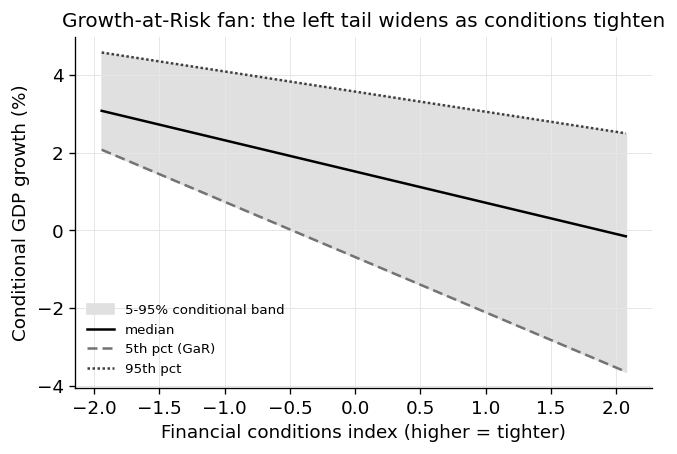

In [5]:
gbar = g.mean()
fci_grid = np.linspace(np.percentile(FCI, 2), np.percentile(FCI, 98), 60)
B = out.set_index("tau")
def qhat(tau, x):
    r = B.loc[tau]
    return r["beta0"] + (r["beta1"] + r["beta2"]) * gbar + r[fci_col] * x
fan = {tau: np.array([qhat(tau, x) for x in fci_grid]) for tau in taus}

cols = _nbstyle.palette(3)
sty = _nbstyle.styles(3)
fig, ax = plt.subplots()
ax.fill_between(fci_grid, fan[0.05], fan[0.95], color="0.88",
                label="5-95% conditional band")
ax.plot(fci_grid, fan[0.50], color=cols[0], linestyle=sty[0], label="median")
ax.plot(fci_grid, fan[0.05], color=cols[1], linestyle=sty[1], label="5th pct (GaR)")
ax.plot(fci_grid, fan[0.95], color=cols[2], linestyle=sty[2], label="95th pct")
ax.set_xlabel("Financial conditions index (higher = tighter)")
ax.set_ylabel("Conditional GDP growth (%)")
ax.set_title("Growth-at-Risk fan: the left tail widens as conditions tighten")
ax.legend(loc="lower left", fontsize=8)
plt.show()

### Figura complementaria — densidades condicionales skew-t, condiciones laxas vs. restrictivas
Siguiendo a ABG (2019), se ajusta la distribución skew-t de Azzalini al conjunto
completo de cuantiles predichos bajo un FCI laxo (percentil 10) y uno restrictivo
(percentil 90). La densidad bajo condiciones restrictivas presenta sesgo negativo
(`alpha < 0`) y un Crecimiento en Riesgo del 5% muy inferior al del caso laxo.

loose: alpha=+0.00  5% GaR=0.90
tight: alpha=-1.96  5% GaR=-2.68


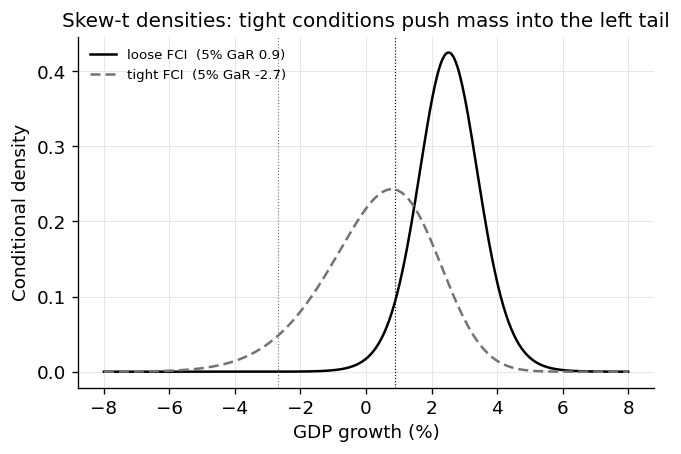

In [6]:
taus_full = (0.05, 0.25, 0.50, 0.75, 0.95)
out_full = qar(g, quantiles=taus_full, horizons=(1,), p=2,
               controls=FCI, n_boot=50, alpha=0.10, seed=11)
Bf = out_full.set_index("tau")
def qdict_at(x):
    return {tau: float(Bf.loc[tau, "beta0"] + (Bf.loc[tau, "beta1"]
                       + Bf.loc[tau, "beta2"]) * gbar + Bf.loc[tau, fci_col] * x)
            for tau in taus_full}

loose_val, tight_val = np.percentile(FCI, 10), np.percentile(FCI, 90)
fit_loose = fit_skewt_to_quantiles(qdict_at(loose_val))
fit_tight = fit_skewt_to_quantiles(qdict_at(tight_val))
gar_loose, gar_tight = fit_loose.downside_quantile(0.05), fit_tight.downside_quantile(0.05)
print(f"loose: alpha={fit_loose.alpha:+.2f}  5% GaR={gar_loose:.2f}")
print(f"tight: alpha={fit_tight.alpha:+.2f}  5% GaR={gar_tight:.2f}")
assert gar_tight < gar_loose, (gar_tight, gar_loose)             # GaR worse when tight
assert fit_tight.alpha < 0.0, fit_tight.alpha                    # left-skewed when tight

xs = np.linspace(-8, 8, 400)
c2 = _nbstyle.palette(2)
fig, ax = plt.subplots()
ax.plot(xs, fit_loose.pdf(xs), color=c2[0], label=f"loose FCI  (5% GaR {gar_loose:.1f})")
ax.plot(xs, fit_tight.pdf(xs), color=c2[1], linestyle=(0, (4, 2)),
        label=f"tight FCI  (5% GaR {gar_tight:.1f})")
ax.axvline(gar_loose, color=c2[0], linewidth=0.7, linestyle=":")
ax.axvline(gar_tight, color=c2[1], linewidth=0.7, linestyle=":")
ax.set_xlabel("GDP growth (%)"); ax.set_ylabel("Conditional density")
ax.set_title("Skew-t densities: tight conditions push mass into the left tail")
ax.legend(loc="upper left", fontsize=8)
plt.show()

**Lectura del resultado.** A lo largo del **abanico** (figura principal) la línea de la
mediana es casi plana en el FCI, mientras que la del percentil 5 se desploma — la banda
5-95 se abre *hacia abajo* a medida que las condiciones se endurecen, la firma visual del
crecimiento vulnerable. Las **densidades skew-t** explicitan el mecanismo: la densidad laxa
es aproximadamente simétrica, pero la restrictiva presenta una asimetría izquierda visible
(`alpha < 0`) con masa adicional empujada hacia la cola inferior. El número principal es el
Crecimiento en Riesgo del 5% — la línea vertical punteada: se ubica en `gar_loose` bajo
condiciones laxas y cae a un `gar_tight` mucho menor cuando las condiciones se endurecen
(`gar_tight < gar_loose`). El mismo desplazamiento que dejó la mediana casi intacta mueve
el escenario adverso en varios puntos de crecimiento — que es justo el sentido de mirar la
cola en lugar del centro.

## Tu turno — elige en qué punto del FCI leer la distribución condicional

La distribución condicional del crecimiento depende de *dónde* se sitúen las condiciones
financieras. A continuación evaluamos el ajuste skew-t completo en un percentil del FCI
elegido (por defecto el 90, bastante restrictivo) y leemos su Crecimiento en Riesgo del 5%
y su mediana. Cambia `fci_pct` y vuelve a ejecutar. Los `assert` posteriores verifican tres
hechos *robustos* que se cumplen en cualquier punto del FCI: los cuantiles predichos son
monótonos en $\tau$, el GaR del 5% nunca supera la mediana, y la skew-t ajustada coloca
≈5% de su masa por debajo de su propio cuantil del 5%. (Deliberadamente **no** verificamos
el indicador `success` del ajuste — el emparejamiento de cuantiles por Nelder-Mead suele
reportar `False` aun cuando los cuantiles ajustados coinciden con tres decimales, de modo
que no es una señal de convergencia fiable.)

In [7]:
# ← change this: the FCI percentile to evaluate the distribution at
#   (0 = loosest conditions in-sample, 100 = tightest).
fci_pct = 90
x_eval = np.percentile(FCI, fci_pct)
qd_you = qdict_at(x_eval)                                # {tau: predicted Q_tau}
fit_you = fit_skewt_to_quantiles(qd_you)
gar5 = fit_you.downside_quantile(0.05)                   # the 5% Growth-at-Risk
med = fit_you.downside_quantile(0.50)                    # the conditional median
cdf_at_gar = float(fit_you.cdf(np.array([gar5]))[0])     # skew-t mass below its own 5% quantile
print(f"FCI pct {fci_pct} (value {x_eval:+.2f}):  5% GaR = {gar5:.2f}   median = {med:.2f}")
print(f"skew-t CDF at the fitted 5% quantile = {cdf_at_gar:.3f}  (target 0.05)")

q_sorted = [qd_you[t] for t in sorted(qd_you)]
assert all(b >= a - 1e-9 for a, b in zip(q_sorted, q_sorted[1:]))   # lower tau -> weakly lower quantile
assert gar5 <= med + 1e-9                                           # 5% GaR never above the median
assert abs(cdf_at_gar - 0.05) < 0.02                                # skew-t cdf recovers the 5% level

FCI pct 90 (value +1.37):  5% GaR = -2.68   median = 0.49
skew-t CDF at the fitted 5% quantile = 0.050  (target 0.05)


**Ejercicios.** (1) *Básico:* fija `fci_pct = 10` (laxo) y vuelve a ejecutar — el GaR del
5% sube (menos riesgo a la baja) mientras las tres aserciones siguen cumpliéndose; la brecha
entre el GaR y la mediana se reduce porque la densidad bajo condiciones laxas es más cercana
a la simetría. (2) *Intermedio:* calcula el GaR en los percentiles 10 y 90 y toma la
diferencia — este *diferencial de Crecimiento en Riesgo* es el número único que ABG usan para
resumir cuánto riesgo a la baja están descontando las condiciones financieras. (3) *Avanzado:*
aumenta el coeficiente de escala del choque negativo `1.6` en §2 (por ejemplo a `2.5`), vuelve
a ejecutar todo el cuaderno y observa cómo el `alpha` de condiciones restrictivas se vuelve más
negativo y el diferencial de GaR se amplía — una cola izquierda más no lineal en el proceso
generador de datos se manifiesta como mayor asimetría en el ajuste.

**¿Qué tan exhaustivo es esto?** `puremacro.gar` es el conjunto de herramientas completo de
crecimiento vulnerable: `qar` (autorregresión cuantílica, usada aquí), `lp_quantile` (la
proyección local *cuantílica* de Adrian-Boyarchenko-Giannone para un panel, cuando se dispone
de una segunda variable), la familia skew-t (`fit_skewt_to_quantiles` / `SkewTFit` con
`skewt_pdf`/`cdf`/`ppf`, más `expected_shortfall` y `downside_entropy`) y `fci` / `fci_rolling`
para el índice de condicionamiento. La cara de volatilidad de "qué tan riesgoso es el mundo"
vive en `puremacro.garch` — volatilidad condicional GARCH(1,1) y DCC (Cuaderno 08) — y ambas se
encuentran en el **Cuaderno 13**, que usa `gar.fci` como uno de los núcleos de un índice de
incertidumbre construido a medida.